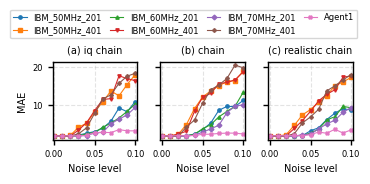

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
PANELS = [
    ("(a) iq chain", "exp01_ibm_baseline+agent__iq_chain__mean_abs_err_MHz(1).csv"),
    ("(b) chain", "exp01_ibm_baseline+agent__chain__mean_abs_err_MHz(1).csv"),
    ("(c) realistic chain", "exp01_ibm_baseline+agent__realistic_chain__mean_abs_err_MHz(1).csv"),
]

# Approx IJCAI single-column width (inches). If your template differs, set this to \columnwidth.
COL_IN = 3.45
# Height tuned for 1x3 subplots + legend on top
H_IN = 1.70

OUT_PNG = "ijcai_singlecol_legend_top.png"
OUT_PDF = "ijcai_singlecol_legend_top.pdf"

# Legend ordering (optional). Any missing methods will be appended.
METHOD_ORDER = [
    "IBM_50MHz_201",
    "IBM_50MHz_401",
    "IBM_60MHz_201",
    "IBM_60MHz_401",
    "IBM_70MHz_201",
    "IBM_70MHz_401",
    "Agent1",
]

# Marker cycle (no fixed colors; matplotlib default color cycle will be used)
MARKERS = ["o", "s", "^", "v", "D", "P", "X", "+", "*"]

# -----------------------------
# Plot style (IJCAI-friendly)
# -----------------------------
plt.rcParams.update(
    {
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "lines.linewidth": 0.8,
        "lines.markersize": 2.4,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)
# line width：0.8 ~ 1.2 最安全
#marker size：2.6 ~ 3.6 最安全

def load_wide_csv(path: str):
    """CSV format: rows=method, columns=noise levels (as strings)."""
    df = pd.read_csv(path)

    # Normalize method names to match your legend (A1 -> Agent1)
    # df["method"] = df["method"].replace({"A1": "Agent1"})

    noise_cols = [c for c in df.columns if c != "method"]
    x = sorted(float(c) for c in noise_cols)
    col_of = {float(c): c for c in noise_cols}

    series = {}
    for _, row in df.iterrows():
        name = row["method"]
        series[name] = [float(row[col_of[n]]) for n in x]

    return x, series


def ordered_methods(methods):
    ordered = [m for m in METHOD_ORDER if m in methods]
    for m in methods:
        if m not in ordered:
            ordered.append(m)
    return ordered


def main():
    fig, axes = plt.subplots(1, 3, figsize=(COL_IN, H_IN), sharey=True)

    for ax, (title, path) in zip(axes, PANELS):
        x, series = load_wide_csv(path)
        methods = ordered_methods(list(series.keys()))

        for i, m in enumerate(methods):
            ax.plot(
                x,
                series[m],
                marker=MARKERS[i % len(MARKERS)],
                label=m,
            )

        ax.set_title(title)
        ax.set_xlabel("Noise level")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_xlim(min(x) - 0.002, max(x) + 0.002)

    axes[0].set_ylabel("MAE")

    # Single legend for the whole figure (moved above all subplots)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=4,  # 7 entries -> wrap into 2 rows
        frameon=True,
        handlelength=1.6,
        columnspacing=1.0,
        borderpad=0.4,
    )

    # Reserve top space for the legend
    fig.subplots_adjust(left=0.12, right=0.99, bottom=0.26, top=0.72, wspace=0.28)

    fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")


if __name__ == "__main__":
    main()
